In [87]:
import fitness_landscape as fl
from fitness_landscape.utils import fasta_to_prot20_sequences
from fitness_landscape.core.sequence import BinarySequence
from fitness_landscape.core.landscape import FitnessLandscape
from fitness_landscape.transforms import eigenmode_decomposition
from fitness_landscape.analysis import (
    calculate_ruggedness_autocorrelation_analytical,
    calculate_ruggedness_autocorrelation_stochastic,
    compute_ruggedness_diffusion_scale,
)
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import pickle
import json
from tqdm import tqdm
import networkx as nx
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from scipy.stats import norm
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.ticker as mticker
from scipy.stats import pearsonr, spearmanr

### SI Figure 1
Attention of high frequency Laplacian eigenmodes by the heat kernel. 

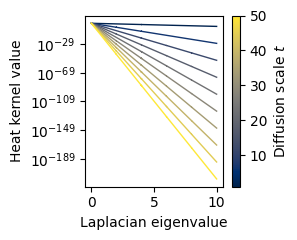

In [27]:
nk = fl.models.nk.create_nk_binary_landscape(N=5, K=3, seed=42)

# Compute eigenmodes of nk model
eigvals, eigvecs = eigenmode_decomposition(
    nk,
    matrix="laplacian",
)

# Range of t values to demonstrate heat kernel
t_range = np.linspace(1, 50, 10)
colors = cm.cividis(np.linspace(0, 1, len(t_range)))

epsilon = 1e-8

fig, ax = plt.subplots(figsize=(3, 2.5))

for t, color in zip(t_range, colors):

    # Compute heat kernel values
    lambda_adjusted = eigvals + epsilon
    h_i = np.exp(-t * lambda_adjusted)

    ax.plot(eigvals, h_i, color=color, lw=1)

ax.set_xlabel("Laplacian eigenvalue")
ax.set_ylabel("Heat kernel value")
ax.set_yscale("log")

norm = mcolors.Normalize(vmin=t_range.min(), vmax=t_range.max())
sm = cm.ScalarMappable(cmap="cividis", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Diffusion scale $t$")

plt.tight_layout()
plt.savefig("../si_figures/si_figure_1/raw_heat_kernel_value.pdf")
plt.show()

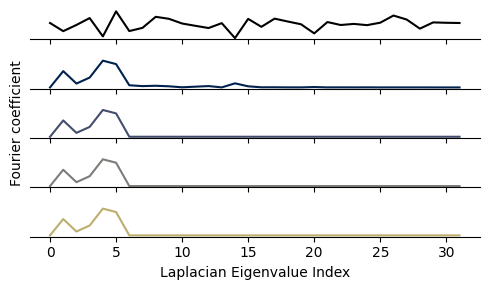

In [28]:

t_range = np.linspace(1, 10, 4)
colors = cm.cividis(np.linspace(0, 1, 5))

total_plots = len(t_range) + 1
fig, axes = plt.subplots(total_plots, 1, figsize=(5, 3), sharex=True)

# Perform graph Fourier transform
eigenvectors, eigenvalues, f_hat = _, _, coefficients = fl.transforms.graph_fourier.graph_fourier_transform(nk)

# Compute the spectral energies of `G`
f_hat_energies = f_hat

# Plot original spectral energies
axes[0].plot(f_hat_energies, color='black')
axes[0].grid(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)
axes[0].tick_params(axis='y', which='both', left=False, labelleft=False)
axes[0].spines['left'].set_visible(False)

# Iterate through t values and plot modified spectral energies
for idx, (t, color) in enumerate(zip(t_range, colors)):

    if idx == 1:
        axes[idx + 1].set_ylabel('Fourier coefficient')

    # Compute the heat kernel values at timestep t
    lambda_adjusted = eigenvalues + epsilon
    h_i = np.exp(-t * lambda_adjusted)

    # Scale the energies of `G` according to the heat kernel eigenvalues
    f_hat_modified = h_i * f_hat

    # Compute the spectral energies of `G` with heat diffusion
    f_hat_modified_energies = np.abs(f_hat_modified)

    axes[idx + 1].plot(f_hat_modified_energies, color=color)
    axes[idx + 1].grid(False)
    axes[idx + 1].spines['right'].set_visible(False)
    axes[idx + 1].spines['top'].set_visible(False)
    axes[idx + 1].spines['left'].set_visible(False)
    axes[idx + 1].tick_params(axis='y', which='both', left=False, labelleft=False)

axes[-1].set_xlabel('Laplacian Eigenvalue Index')

plt.tight_layout()
plt.savefig("../si_figures/si_figure_1/heat_kernel_spectral_energies.pdf")
plt.show()

### SI Figure 2
Comaprison of ruggedness indicators in dense NK landscape.

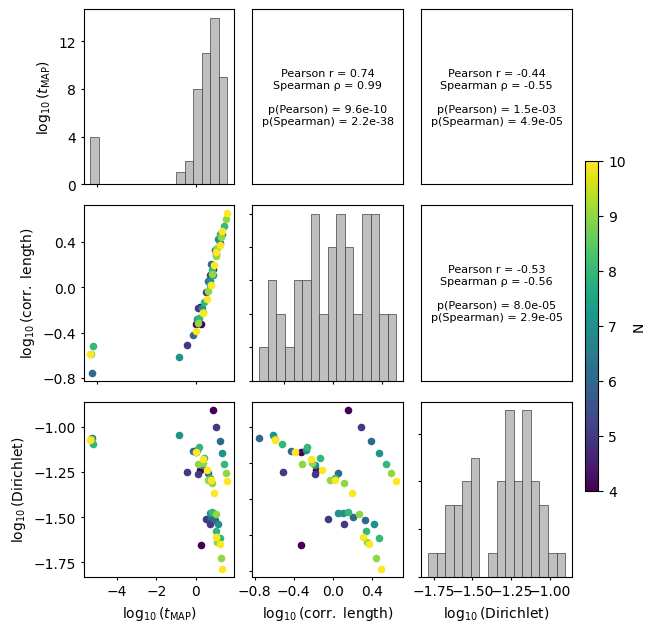

In [29]:
tmap_dict = {}
auto_cor_dict = {}
dirichlet_dict = {}

# Range of N variables to consider
n_range = list(range(4, 11))

# Define K up to N-1 for each N
for n_param in n_range:
    k_range = list(range(0, n_param))
    
    # Construct NK landscapes and compute diffusion map for each (N, K)

    for k_param in k_range:
        nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=k_param, seed=42)
        tmap_dict[(n_param, k_param)] = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(nk, t_min=1e-10, t_max=1e2)
        auto_cor_dict[(n_param, k_param)] = fl.analysis.random_walk.calculate_ruggedness_autocorrelation_analytical(nk)
        dirichlet_dict[(n_param, k_param)] = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(nk)

# Indicator vs. N and K parameters in NK model
rows = []
for (N, K), tmap_res in tmap_dict.items():
    rows.append({
        "N": int(N),
        "K": int(K),
        "t_map": float(tmap_res["t_map"]),
        "corr_len": float(auto_cor_dict[(N, K)]["correlation_length"]),
        "dirichlet": float(dirichlet_dict[(N, K)]["total_dirichlet_energy"]),
    })
df = pd.DataFrame(rows).sort_values(["N", "K"]).reset_index(drop=True)

# Comparison of different ruggedness metrics under ideal conditions
df_plot = df.copy()

# log-transform
eps = 1e-12
df_plot["log_tmap"] = np.log10(df_plot["t_map"] + eps)
df_plot["log_corr"] = np.log10(df_plot["corr_len"] + eps)
df_plot["log_dir"]  = np.log10(df_plot["dirichlet"] + eps)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from scipy.stats import pearsonr, spearmanr

cols = ["log_tmap", "log_corr", "log_dir"]
labels = [r"$\log_{10}(t_{\mathrm{MAP}})$",
          r"$\log_{10}(\mathrm{corr.\ length})$",
          r"$\log_{10}(\mathrm{Dirichlet})$"]

Ns = sorted(df_plot["N"].unique())
cmap = cm.viridis
colors = {N: cmap(i/(len(Ns)-1 if len(Ns) > 1 else 1)) for i, N in enumerate(Ns)}

def p_bound(p):
    if (p == 0) or (p < 1e-50):
        return "< 1e-50"
    return f"= {p:.1e}"

fig, axes = plt.subplots(3, 3, figsize=(6.6, 6.6), constrained_layout=False)
fig.subplots_adjust(left=0.12, right=0.86, bottom=0.12, top=0.98, wspace=0.12, hspace=0.12)

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        x = df_plot[cols[j]].to_numpy()
        y = df_plot[cols[i]].to_numpy()

        if i == j:
            ax.hist(x, bins=16, color="0.75", edgecolor="0.25", linewidth=0.5)
        elif i > j:
            for N in Ns:
                sub = df_plot[df_plot["N"] == N]
                ax.scatter(sub[cols[j]], sub[cols[i]],
                           s=20, alpha=1, color=colors[N], linewidths=1)
        else:
            r_p, p_p = pearsonr(x, y)
            r_s, p_s = spearmanr(x, y)

            txt = (
                f"Pearson r = {r_p:.2f}\n"
                f"Spearman ρ = {r_s:.2f}\n\n"
                f"p(Pearson) {p_bound(p_p)}\n"
                f"p(Spearman) {p_bound(p_s)}"
            )
            ax.text(0.5, 0.5, txt, ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, linespacing=1.25)

            ax.set_xticks([])
            ax.set_yticks([])

        if i < 2:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

        ax.tick_params(length=2, width=0.8)

for i in range(3):
    axes[i, 0].set_ylabel(labels[i], fontsize=10)
for j in range(3):
    axes[2, j].set_xlabel(labels[j], fontsize=10)

for ax in axes[2, :]:
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
for ax in axes[:, 0]:
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4))

cax = fig.add_axes([0.88, 0.25, 0.02, 0.50])  # [left, bottom, width, height]
norm = mcolors.Normalize(vmin=min(Ns), vmax=max(Ns))
sm = cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("N", rotation=90)

plt.savefig("../si_figures/si_figure_2/laplacian_indicators_correlogram_clean.pdf")
plt.show()

### SI Figure 3
Comparison of ruggedness indicators under challenging spectral conditions.
1. Spectral complexity:
Build signals as controlled mixtures of Laplacian eigenvectors:
f = \sqrt{1-\alpha}\, v_{j_\text{low}} + \sqrt{\alpha}\, v_{j_\text{high}}

2. Topological complexity:


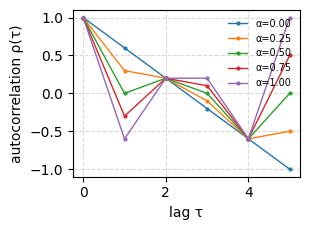

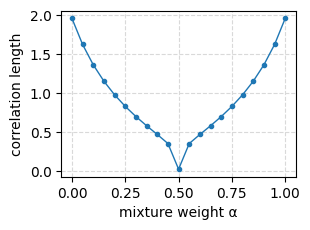

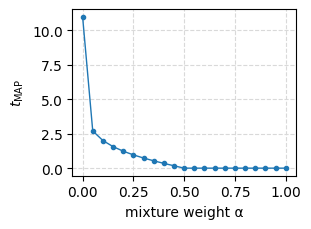

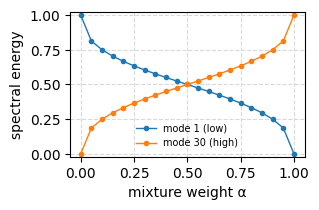

In [86]:
# Spectral imbalance by mixing two eigenmodes

nk = fl.models.nk.create_nk_binary_landscape(N=5, K=0, seed=42)

eigvals, eig_vecs = eigenmode_decomposition(
    nk,
    matrix="laplacian",
)

low_index  = 1
high_index = -2

# cache components once
low_comp  = eig_vecs[:, low_index].astype(float)
high_comp = eig_vecs[:, high_index].astype(float)

# alpha sweep
alpha_grid = np.linspace(0, 1, 21)

rows = []

for a_idx, alpha in enumerate(alpha_grid):
    alpha = float(alpha)

    # Mixture in an orthonormal eigenbasis: sqrt-weights keep ||f|| stable
    f = np.sqrt(1.0 - alpha) * low_comp + np.sqrt(alpha) * high_comp

    # safer layer name
    layer_name = f"combined_eigvecs_low{low_index}_high{high_index}_a{a_idx:02d}"
    nk.attach(name=layer_name, values=f, dtype="numeric")
    nk.view(layer_name)

    # tMAP
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
        nk, t_min=1e-10, t_max=1e2
    )

    # autocorrelation
    ac_res = fl.analysis.random_walk.calculate_ruggedness_autocorrelation_analytical(
        nk, lag_max=None
    )
    rho = np.asarray(ac_res["autocorrelation"], dtype=float)

    # GFT coefficients 
    # returns (eigvals, eigvecs, coeffs) 
    _, _, coeffs = fl.transforms.graph_fourier.graph_fourier_transform(nk)
    coeffs = np.asarray(coeffs, dtype=float)

    E = np.abs(coeffs)
    E = E / (E.sum() if E.sum() > 0 else 1.0)

    rows.append({
        "alpha": alpha,
        "layer": layer_name,

        "t_map": float(tmap_res["t_map"]),
        "t_lo": float(tmap_res["t_lower_confidence_interval"]),
        "t_hi": float(tmap_res["t_upper_confidence_interval"]),
        "t_logpost_map": float(tmap_res["t_logposterior_map"]),
        "t_var_approx": float(tmap_res["variance_approximate"]),

        "corr_len": float(ac_res["correlation_length"]),

        "rho": rho,
        "rho_len": int(len(rho)),
        "rho_lag1": float(rho[1]) if len(rho) > 1 else np.nan,
        "rho_min": float(np.min(rho)) if len(rho) else np.nan,

        # store spectral energy vector for plotting
        "E": E,
    })

df = pd.DataFrame(rows)
df["log_tmap"] = np.log(df["t_map"].clip(lower=1e-300))

# guard correlation length
df["log_corr_len"] = np.log(df["corr_len"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(3.2, 2.4))

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    i = int(np.argmin(np.abs(df["alpha"].to_numpy() - alpha)))
    rho = df.loc[i, "rho"]
    ax.plot(np.arange(len(rho)), rho, lw=1, marker="o", ms=2, label=f"α={df.loc[i,'alpha']:.2f}")

ax.set_xlabel("lag τ")
ax.set_ylabel("autocorrelation ρ(τ)")
ax.grid(True, ls="--", c="0.85")
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/autocorrelation_mixtures.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(3.2, 2.4))
ax.plot(df["alpha"], df["corr_len"], marker="o", ms=3, lw=1)

ax.set_xlabel("mixture weight α")
ax.set_ylabel("correlation length")
ax.grid(True, ls="--", c="0.85")
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/autocorrelation_vs_alpha.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(3.2, 2.4))
ax.plot(df["alpha"], df["t_map"], marker="o", ms=3, lw=1)

# ax.set_yscale("log")
ax.set_xlabel("mixture weight α")
ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
ax.grid(True, which="both", ls="--", c="0.85")
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/tmap_vs_alpha.pdf")
plt.show()


# Plot GFT components
eps = 1e-300

# Use "power" spectrum; more standard than |c|
def gft_energy(coeffs):
    c = np.asarray(coeffs, float)
    P = np.abs(c)**2
    return P / (P.sum() + eps)

# Extract energy in the two modes you mixed
E_low  = []
E_high = []
for i in range(len(df)):
    E = df.loc[i, "E"]            # if you already stored E as power, keep it
    # otherwise recompute from stored coeffs (recommended to store coeffs too)
    E_low.append(E[low_index])
    E_high.append(E[high_index])

E_low = np.array(E_low)
E_high = np.array(E_high)

fig, ax = plt.subplots(figsize=(3.2, 2.2))
ax.plot(df["alpha"], E_low,  marker="o", ms=3, lw=1, label=f"mode 1 (low)")
ax.plot(df["alpha"], E_high, marker="o", ms=3, lw=1, label=f"mode 30 (high)")
ax.set_xlabel("mixture weight α")
ax.set_ylabel("spectral energy")
ax.set_ylim(-0.02, 1.02)
ax.grid(True, ls="--", c="0.85")
ax.legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/spectral_contribution_vs_alpha.pdf")
plt.show()


In [ ]:
# Topological bottlenecks

# Landscapy convenience functions
def landscape_from_graph(G):
    G = nx.convert_node_labels_to_integers(G)
    n = G.number_of_nodes()
    L = int(np.ceil(np.log2(n)))
    seqs = [BinarySequence.from_integer_bits(i, length=L) for i in range(n)]
    for i, seq in enumerate(seqs):
        G.nodes[i]["sequence"] = seq
    return FitnessLandscape.from_graph(G)

def graph_metrics(G):
    # Laplacian spectrum for topology descriptors
    w, U = eigenmode_decomposition(G, matrix="laplacian")
    w = np.asarray(w, float)
    lam2 = float(np.sort(w)[1]) if len(w) > 1 else np.nan

    deg = np.array([d for _, d in G.degree()], float)
    deg_cv = float(deg.std() / (deg.mean() + 1e-12))

    if nx.is_connected(G):
        asp = float(nx.average_shortest_path_length(G))
        diam = float(nx.diameter(G))
    else:
        asp, diam = np.nan, np.nan

    return dict(lambda2=lam2, deg_cv=deg_cv, asp=asp, diam=diam, n=G.number_of_nodes(), m=G.number_of_edges())

def make_signal_from_graph(G, alpha, rng, mode="fiedler_vs_high", hi_frac=0.2):
    w, U = eigenmode_decomposition(G, matrix="laplacian")
    w = np.asarray(w, float)
    U = np.asarray(U, float)

    # low component: Fiedler (module separator / smoothest non-constant)
    v_low = U[:, 1]

    # choose a high-frequency eigenvector from the top band
    n = len(w)
    hi_start = int((1.0 - hi_frac) * n)
    hi_band = np.arange(max(2, hi_start), n)   # skip 0/1
    j_high = int(rng.choice(hi_band))
    v_high = U[:, j_high]

    f = np.sqrt(1 - alpha) * v_low + np.sqrt(alpha) * v_high

    # normalize signal variance so scale doesn’t confound
    f = (f - f.mean()) / (f.std() + 1e-12)

    return f, dict(j_high=j_high, eig_high=float(w[j_high]))

def evaluate_graph(G, graph_name, alpha_grid, n_reps=25, seed=0, lag_max=None):
    rng = np.random.default_rng(seed)
    rows = []

    topo = graph_metrics(G)

    L = landscape_from_graph(G)

    for alpha in alpha_grid:
        for rep in range(n_reps):
            f, meta = make_signal_from_graph(G, alpha=float(alpha), rng=rng)
            
            layer_name = f"mix_a{int(alpha*100):02d}_rep{rep:02d}"
            L.add(name=layer_name, values=f, dtype="numeric")
            L.view(layer_name)

            ac = calculate_ruggedness_autocorrelation_analytical(L, lag_max=lag_max)
            tm = compute_ruggedness_diffusion_scale(L, t_min=1e-10, t_max=1e2)

            rho = np.asarray(ac["autocorrelation"], float)
            rows.append({
                "graph": graph_name,
                "alpha": float(alpha),
                "rep": int(rep),
                **topo,
                **meta,
                "corr_len": float(ac["correlation_length"]),
                "rho_min": float(np.min(rho)),
                "rho_lag1": float(rho[1]) if len(rho) > 1 else np.nan,
                "rho_sign_flips": int(np.sum(np.sign(rho[1:])[:-1] * np.sign(rho[1:])[1:] < 0)),
                "t_map": float(tm["t_map"]),
                "t_lo": float(tm["t_lower_confidence_interval"]),
                "t_hi": float(tm["t_upper_confidence_interval"]),
                "t_ci_width": float(tm["t_upper_confidence_interval"] - tm["t_lower_confidence_interval"]),
            })

    df = pd.DataFrame(rows)
    df["log_tmap"] = np.log10(np.maximum(df["t_map"].to_numpy(), 1e-300))
    return df



6it [00:57,  9.53s/it]


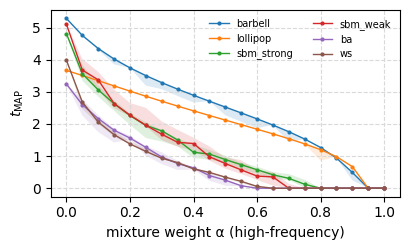

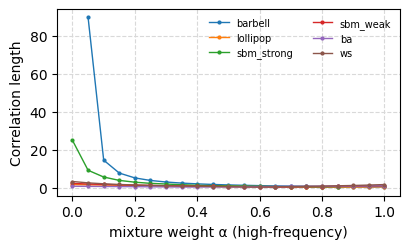

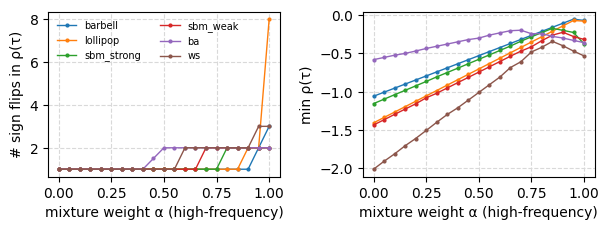

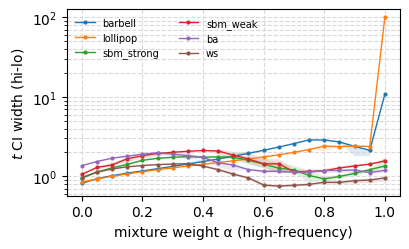

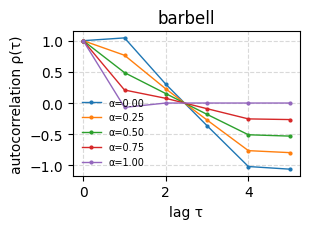

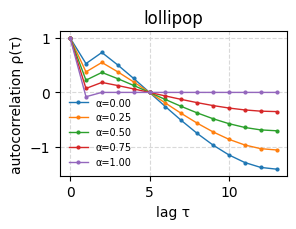

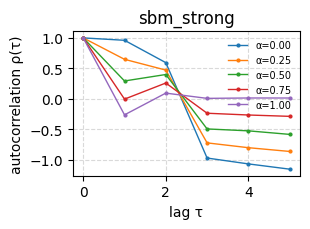

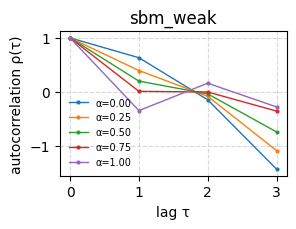

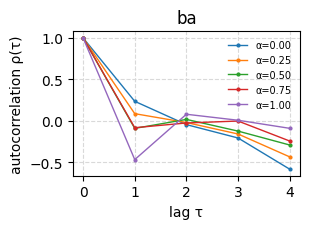

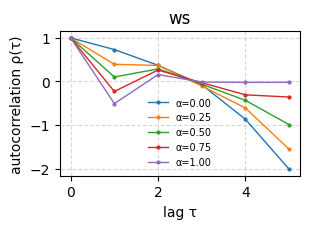

In [103]:

# Construct pathogenic graphs.
alpha_grid = np.linspace(0, 1, 21)

graphs = {
    "barbell": nx.barbell_graph(16, 2),# extreme bottleneck
    "lollipop": nx.lollipop_graph(20, 12),# clique + path
    "sbm_strong": nx.stochastic_block_model([16,16], [[0.5,0.01],[0.01,0.5]], seed=1),
    "sbm_weak": nx.stochastic_block_model([16,16], [[0.5,0.1],[0.1,0.5]], seed=2),
    "ba": nx.barabasi_albert_graph(32, 3, seed=3),# huby
    "ws": nx.watts_strogatz_graph(32, 4, 0.2, seed=4),# small-world-ish
}
n_reps = 30
seed = 0
lag_max = None

graphs_to_run = {
    "barbell": graphs["barbell"],
    "lollipop": graphs["lollipop"],
    "sbm_strong": graphs["sbm_strong"],
    "sbm_weak": graphs["sbm_weak"],
    "ba": graphs["ba"],
    "ws": graphs["ws"],
}

rng_master = np.random.default_rng(seed)
rows = []

for graph_name, G in graphs_to_run.items():
    topo = graph_metrics(G)
    L = landscape_from_graph(G)

    for ai, alpha in enumerate(alpha_grid):
        for rep in range(n_reps):

            sub_seed = int(rng_master.integers(0, 2**32 - 1))
            rng = np.random.default_rng(sub_seed)

            f, meta = make_signal_from_graph(G, alpha=float(alpha), rng=rng)

            layer_name = f"{graph_name}_a{int(round(alpha*100)):03d}_r{rep:03d}"
            L.add(name=layer_name, values=f, dtype="numeric")
            L.view(layer_name)

            ac = calculate_ruggedness_autocorrelation_analytical(L, lag_max=lag_max)
            tm = compute_ruggedness_diffusion_scale(L, t_min=1e-10, t_max=1e2)

            rho = np.asarray(ac["autocorrelation"], dtype=float)

            rows.append({
                "graph": graph_name,
                "alpha": float(alpha),
                "rep": int(rep),
                **topo,
                **meta,
                "corr_len": float(ac["correlation_length"]),
                "rho_lag1": float(rho[1]) if len(rho) > 1 else np.nan,
                "rho_min": float(np.min(rho)) if len(rho) else np.nan,
                "rho_sign_flips": int(np.sum(np.sign(rho[1:])[:-1] * np.sign(rho[1:])[1:] < 0)) if len(rho) > 2 else 0,
                "t_map": float(tm["t_map"]),
                "t_lo": float(tm["t_lower_confidence_interval"]),
                "t_hi": float(tm["t_upper_confidence_interval"]),
            })

df_all = pd.DataFrame(rows)
df_all["log_tmap"] = np.log10(df_all["t_map"].clip(lower=1e-300))
df_all["t_ci_width"] = df_all["t_hi"] - df_all["t_lo"]
df_all["log_t_ci_width"] = np.log10(df_all["t_ci_width"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(4.2, 2.6))

for graph_name in graphs_to_run.keys():
    sub = df_all[df_all["graph"] == graph_name]
    g = sub.groupby("alpha")
    x = g["alpha"].first().to_numpy()
    med = g["t_map"].median().to_numpy()
    q1 = g["t_map"].quantile(0.25).to_numpy()
    q3 = g["t_map"].quantile(0.75).to_numpy()

    ax.plot(x, med, lw=1, marker="o", ms=2, label=graph_name)
    ax.fill_between(x, q1, q3, alpha=0.15)

ax.set_xlabel("mixture weight α (high-frequency)")
ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
ax.grid(True, which="both", ls="--", c="0.85")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/tmap_vs_alpha_all_graphs.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 2.6))

for graph_name in graphs_to_run.keys():
    sub = df_all[df_all["graph"] == graph_name]
    g = sub.groupby("alpha")
    x = g["alpha"].first().to_numpy()
    med = g["corr_len"].median().to_numpy()
    q1 = g["corr_len"].quantile(0.25).to_numpy()
    q3 = g["corr_len"].quantile(0.75).to_numpy()

    ax.plot(x, med, lw=1, marker="o", ms=2, label=graph_name)
    ax.fill_between(x, q1, q3, alpha=0.15)

ax.set_xlabel("mixture weight α (high-frequency)")
ax.set_ylabel("Correlation length")
ax.grid(True, ls="--", c="0.85")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig("../si_figures/si_figure_3/corr_len_vs_alpha_all_graphs.pdf")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.4), sharex=True)

ax = axes[0]
for graph_name in graphs_to_run.keys():
    sub = df_all[df_all["graph"] == graph_name]
    g = sub.groupby("alpha")
    x = g["alpha"].first().to_numpy()
    med = g["rho_sign_flips"].median().to_numpy()
    ax.plot(x, med, lw=1, marker="o", ms=2, label=graph_name)
ax.set_xlabel("mixture weight α (high-frequency)")
ax.set_ylabel("# sign flips in ρ(τ)")
ax.grid(True, ls="--", c="0.85")

ax = axes[1]
for graph_name in graphs_to_run.keys():
    sub = df_all[df_all["graph"] == graph_name]
    g = sub.groupby("alpha")
    x = g["alpha"].first().to_numpy()
    med = g["rho_min"].median().to_numpy()
    ax.plot(x, med, lw=1, marker="o", ms=2, label=graph_name)
ax.set_xlabel("mixture weight α (high-frequency)")
ax.set_ylabel("min ρ(τ)")
ax.grid(True, ls="--", c="0.85")

axes[0].legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 2.6))

for graph_name in graphs_to_run.keys():
    sub = df_all[df_all["graph"] == graph_name]
    g = sub.groupby("alpha")
    x = g["alpha"].first().to_numpy()
    med = g["t_ci_width"].median().to_numpy()
    q1 = g["t_ci_width"].quantile(0.25).to_numpy()
    q3 = g["t_ci_width"].quantile(0.75).to_numpy()

    ax.plot(x, med, lw=1, marker="o", ms=2, label=graph_name)
    ax.fill_between(x, q1, q3, alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("mixture weight α (high-frequency)")
ax.set_ylabel(r"$t$ CI width (hi-lo)")
ax.grid(True, which="both", ls="--", c="0.85")
ax.legend(frameon=False, fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

alphas_show = (0.0, 0.25, 0.5, 0.75, 1.0)

for graph_name, G in graphs_to_run.items():
    L = landscape_from_graph(G)
    rng = np.random.default_rng(seed)

    fig, ax = plt.subplots(figsize=(3.2, 2.4))
    for i, a in enumerate(alphas_show):
        f, _ = make_signal_from_graph(G, alpha=float(a), rng=rng)
        layer_name = f"{graph_name}_example_a{int(round(a*100)):03d}_{i:02d}"
        L.add(name=layer_name, values=f, dtype="numeric")
        L.view(layer_name)

        ac = calculate_ruggedness_autocorrelation_analytical(L, lag_max=lag_max)
        rho = np.asarray(ac["autocorrelation"], dtype=float)

        ax.plot(np.arange(len(rho)), rho, marker="o", ms=2, lw=1, label=f"α={a:.2f}")

    ax.set_title(graph_name)
    ax.set_xlabel("lag τ")
    ax.set_ylabel("autocorrelation ρ(τ)")
    ax.grid(True, ls="--", c="0.85")
    ax.legend(frameon=False, fontsize=7)
    plt.tight_layout()
    plt.show()

### SI Figure 4
Comparison of epistasis (algebraic) and ruggedness (geometric).

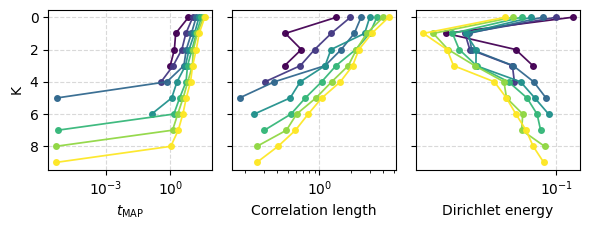

In [121]:
# Ruggedness indicators vs. N and K in NK model

tmap_dict = {}
auto_cor_dict = {}
dirichlet_dict = {}

# Range of N variables to consider
n_range = list(range(4, 11))

# Define K up to N-1 for each N
for n_param in n_range:
    k_range = list(range(0, n_param))
    
    # Construct NK landscapes and compute diffusion map for each (N, K)

    for k_param in k_range:
        nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=k_param, seed=42)
        tmap_dict[(n_param, k_param)] = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(nk, t_min=1e-10, t_max=1e2)
        auto_cor_dict[(n_param, k_param)] = fl.analysis.random_walk.calculate_ruggedness_autocorrelation_analytical(nk)
        dirichlet_dict[(n_param, k_param)] = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(nk)

# Indicator vs. N and K parameters in NK model
rows = []
for (N, K), tmap_res in tmap_dict.items():
    rows.append({
        "N": int(N),
        "K": int(K),
        "t_map": float(tmap_res["t_map"]),
        "corr_len": float(auto_cor_dict[(N, K)]["correlation_length"]),
        "dirichlet": float(dirichlet_dict[(N, K)]["total_dirichlet_energy"]),
    })
df = pd.DataFrame(rows).sort_values(["N", "K"]).reset_index(drop=True)

Ns = sorted(df["N"].unique())
cmap = cm.viridis
colors = {N: cmap(i/(len(Ns)-1 if len(Ns) > 1 else 1)) for i, N in enumerate(Ns)}

fig, axes = plt.subplots(1, 3, figsize=(6, 2.4), sharey=True)
fig.subplots_adjust(right=0.88, wspace=0.35)  

x_cols   = ["t_map", "corr_len", "dirichlet"]
x_labels = [r"$t_{\mathrm{MAP}}$", "Correlation length", "Dirichlet energy"]

for ax, xcol, xlabel in zip(axes, x_cols, x_labels):
    for N in Ns:
        sub = df[df["N"] == N].sort_values("K")
        ax.plot(
            sub[xcol].to_numpy(),
            sub["K"].to_numpy(),
            color=colors[N],
            lw=1.25,
            marker="o",
            markersize=4,
            alpha=0.95
        )
    ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.grid(True, ls="--", c="0.85")
    ax.invert_yaxis()

axes[0].set_ylabel("K")
fig.subplots_adjust(wspace=0.35)

ax_dir = axes[2]

# Fewer ticks on log axis
ax_dir.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=4))
ax_dir.xaxis.set_minor_locator(mticker.NullLocator())  # remove minor ticks entirely

# Compact scientific formatting (10^x style)
ax_dir.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10.0))

plt.tight_layout()
plt.savefig("../si_figures/si_figure_4/nk_k_n_vs_ruggedness_indicators.pdf")
plt.show()

/tmp/ipykernel_84415/229468630.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 0.90, 1.0])


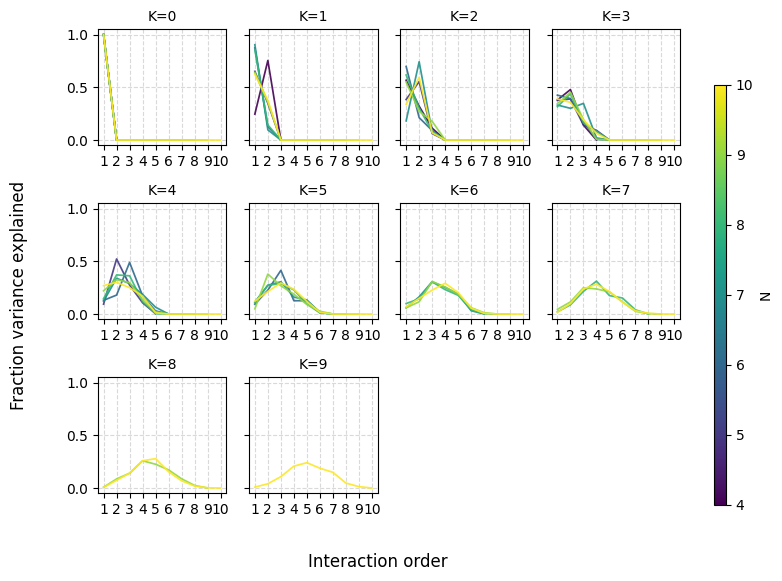

In [117]:
# Epistasis quantification at different N and K in NK model

rows = []

n_range = list(range(4, 11))

for n_param in n_range:
    for k_param in range(0, n_param):
        nk = fl.models.nk.create_nk_binary_landscape(N=n_param, K=k_param, seed=42)

        max_order = min(n_param, k_param + 1)  # NK interactions are bounded like this
        res = fl.analysis.epistasis.calculate_epistasis_walsh(nk, order=max_order)

        var_by_order = res.get("variance_explained", {})  # {order:int -> fraction}

        # Ensure we include missing orders as zeros for consistent plotting later
        for o in range(1, n_param + 1):
            rows.append({
                "N": n_param,
                "K": k_param,
                "order": o,
                "var_explained": float(var_by_order.get(o, 0.0))
            })

df_epi = pd.DataFrame(rows)

Ks = sorted(df_epi["K"].unique())
Ns = sorted(df_epi["N"].unique())

cmap = cm.viridis
colors = {N: cmap(i/(len(Ns)-1 if len(Ns) > 1 else 1)) for i, N in enumerate(Ns)}

ncols = 4
nrows = int(np.ceil(len(Ks) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 6), sharex=False, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, K in zip(axes, Ks):
    subK = df_epi[df_epi["K"] == K]

    for N in Ns:
        sub = subK[subK["N"] == N].sort_values("order")
        sub = sub[sub["order"] <= N]

        ax.plot(
            sub["order"].to_numpy(),
            sub["var_explained"].to_numpy(),
            color=colors[N],
            lw=1.25,
            alpha=0.9
        )

    ax.set_title(f"K={K}", fontsize=10)
    ax.grid(True, ls="--", c="0.85")

for ax in axes[len(Ks):]:
    ax.axis("off")

for ax in axes[:len(Ks)]:  # only the used axes
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))

fig.supxlabel("Interaction order", y=0.04)
fig.supylabel("Fraction variance explained", x=0.04)

cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
norm = mcolors.Normalize(vmin=min(Ns), vmax=max(Ns))
sm = cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("N")

plt.tight_layout(rect=[0.05, 0.05, 0.90, 1.0])
plt.savefig("../si_figures/si_figure_4/si_nk_epistasis_variance_by_order_byK.pdf")
plt.show()